# Predict Obesity Level (Multi‑Class Classification)

**Goal:** Predict **obesity level** from lifestyle + physical condition features.

✅ Includes:
- Upload CSV **or** Kaggle API option
- Data cleaning
- EDA (several visual questions)
- Feature engineering (**BMI**)
- Preprocessing (**One‑Hot Encoding + Scaling**)
- Train models: **Naive Bayes, Logistic Regression, SVM (Calibrated for probabilities)**  
  *(Plus a few optional extra models for comparison)*
- Metrics + plots
- Save best model for **Streamlit** + `schema.json` for auto UI inputs

**Dataset:** Kaggle “Obesity Levels”  
Common file: `ObesityDataSet_raw_and_data_sinthetic.csv`  
Target column: `NObeyesdad`

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# 1) Imports
# =========================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Optional extra models (nice for comparison slides)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
import joblib

print("Ready ")

Ready 


## 2) Load dataset

### Option A: Upload CSV (recommended)
Upload your dataset CSV from Kaggle.

### Option B: Kaggle API download (optional)
Upload `kaggle.json` and run the Kaggle cell.

In [3]:
# =========================
# Option A: Upload CSV
# =========================
from google.colab import files

uploaded = files.upload()  # choose your dataset .csv
print("Uploaded:", list(uploaded.keys()))

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic (1).csv
Uploaded: ['ObesityDataSet_raw_and_data_sinthetic (1).csv']


In [4]:
# =========================
# Option B: Kaggle API download (optional)
# =========================
# Uncomment if you want to download via Kaggle API.
# Steps:
# 1) Create Kaggle API token (kaggle.json)
# 2) Upload it in this cell
# 3) Run this cell

# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !pip -q install kaggle
# !kaggle datasets download -d fatemehmehrparvar/obesity-levels -p /content --unzip
# !ls -lah /content

In [5]:
# =========================
# Read CSV (auto-detect first .csv in /content)
# =========================
CSV_PATH = None
for fn in os.listdir("/content"):
    if fn.lower().endswith(".csv"):
        CSV_PATH = os.path.join("/content", fn)
        break

if CSV_PATH is None:
    raise FileNotFoundError("No CSV found in /content. Upload your dataset CSV or download via Kaggle API.")

print("Using CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))

Using CSV: /content/ObesityDataSet_raw_and_data_sinthetic.csv
Shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Columns: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']


In [6]:
print(df.shape)

(2111, 17)


# Data Cleaning

In [7]:
# =========================
# 3) Validate columns + basic cleaning
# =========================
TARGET = "NObeyesdad"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Please check your CSV column names.")

# Drop missing + duplicates (safe default)
df = df.dropna().drop_duplicates()

# Convert target to string labels
df[TARGET] = df[TARGET].astype(str)

print("Rows after cleaning:", len(df))
print("Number of classes:", df[TARGET].nunique())
display(df[TARGET].value_counts())

Rows after cleaning: 2087
Number of classes: 7


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_II,290
Normal_Weight,282
Overweight_Level_I,276
Insufficient_Weight,267


In [8]:
# Quick check for missing values per column
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

,0


# EDA
We’ll answer a few simple questions with quick charts (matplotlib only).

In [9]:
# Helper: safe histogram plot
def hist_plot(series, title, bins=30):
    plt.figure(figsize=(6,4))
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Helper: bar plot counts
def bar_counts(series, title):
    counts = series.value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

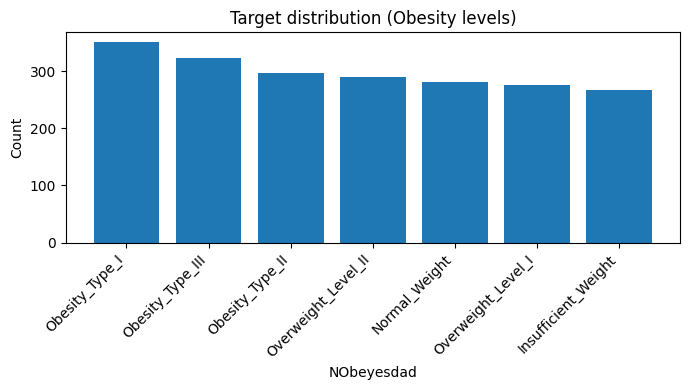

In [10]:
# Target distribution
bar_counts(df[TARGET], "Target distribution (Obesity levels)")

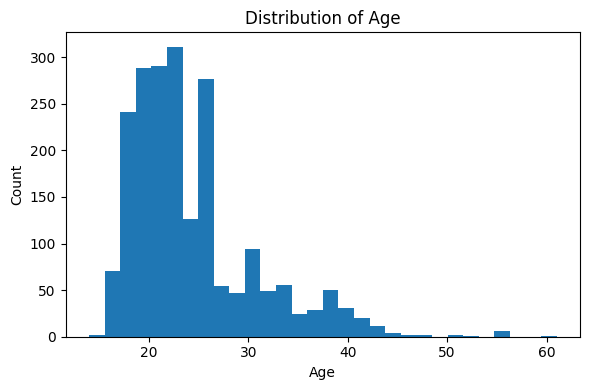

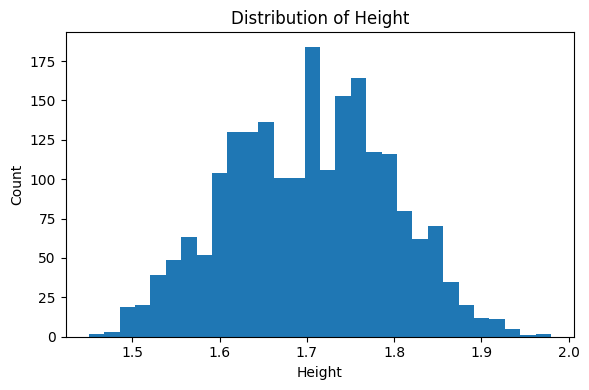

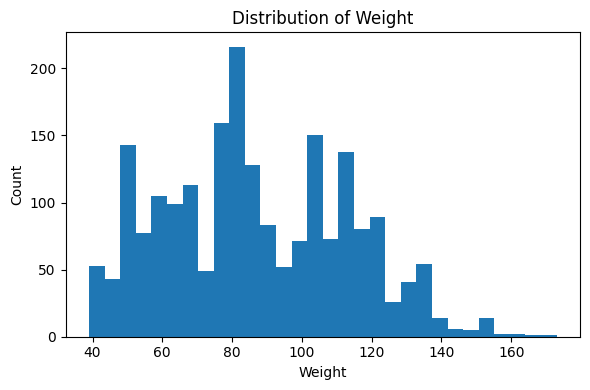

In [11]:
# Numeric feature overview (if present)
for col in ["Age", "Height", "Weight"]:
    if col in df.columns:
        hist_plot(df[col], f"Distribution of {col}")

# How do Age and Weight relate to each other?

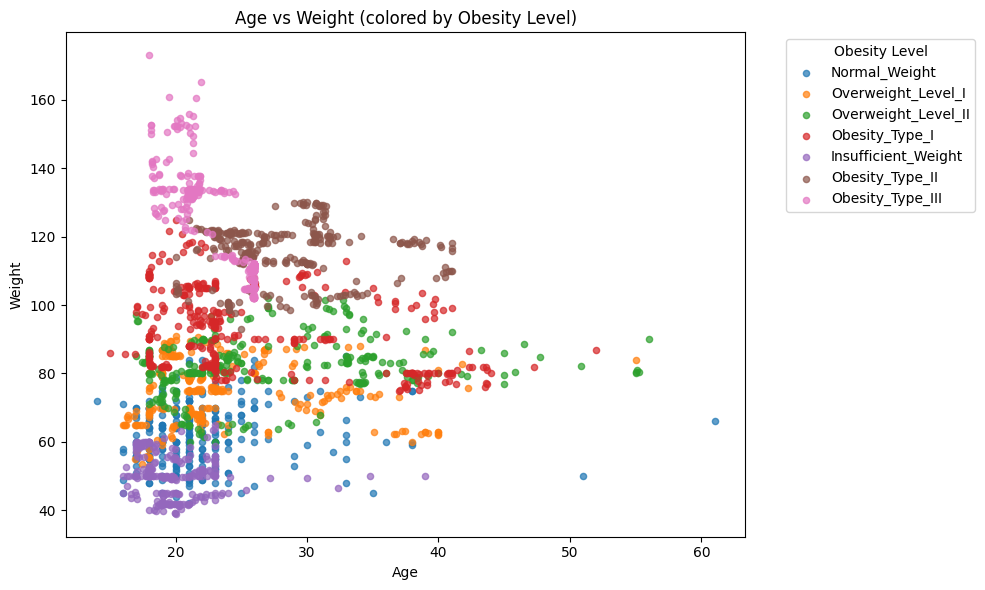

In [12]:
if "Age" in df.columns and "Weight" in df.columns and "NObeyesdad" in df.columns:
    plt.figure(figsize=(10, 6))

    # Get unique obesity levels and create color map
    obesity_levels = df["NObeyesdad"].unique()
    colors = plt.cm.tab10(range(len(obesity_levels)))

    for level, color in zip(obesity_levels, colors):
        mask = df["NObeyesdad"] == level
        plt.scatter(df.loc[mask, "Age"], df.loc[mask, "Weight"],
                   s=20, alpha=0.7, label=level, color=color)

    plt.title("Age vs Weight (colored by Obesity Level)")
    plt.xlabel("Age")
    plt.ylabel("Weight")
    plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Age/Weight/NObeyesdad columns not found in this CSV.")

# Does family history with overweight affect obesity type?

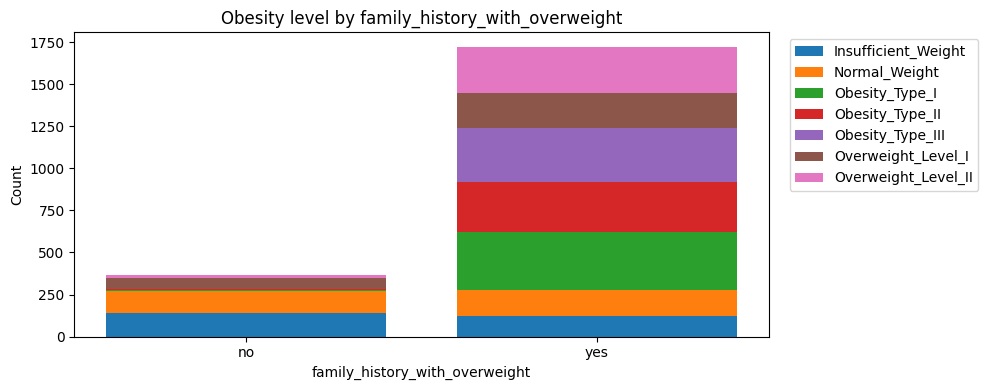

In [13]:
if "family_history_with_overweight" in df.columns:
    # Group counts by family history
    pivot = pd.crosstab(df["family_history_with_overweight"].astype(str), df[TARGET])
    plt.figure(figsize=(10,4))
    # stacked bars
    bottom = np.zeros(len(pivot.index))
    for cls in pivot.columns:
        plt.bar(pivot.index, pivot[cls].values, bottom=bottom, label=cls)
        bottom += pivot[cls].values
    plt.title("Obesity level by family_history_with_overweight")
    plt.xlabel("family_history_with_overweight")
    plt.ylabel("Count")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'family_history_with_overweight' not found.")

# Does eating food between meals affect obesity type?

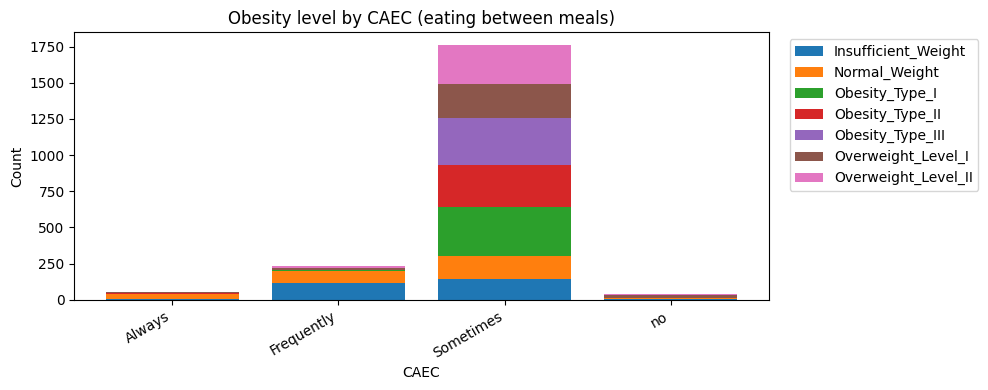

In [14]:
if "CAEC" in df.columns:
    pivot = pd.crosstab(df["CAEC"].astype(str), df[TARGET])
    plt.figure(figsize=(10,4))
    bottom = np.zeros(len(pivot.index))
    for cls in pivot.columns:
        plt.bar(pivot.index, pivot[cls].values, bottom=bottom, label=cls)
        bottom += pivot[cls].values
    plt.title("Obesity level by CAEC (eating between meals)")
    plt.xlabel("CAEC")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'CAEC' not found.")

# Feature Engineering
We add **BMI** if Height and Weight exist.

Added BMI 


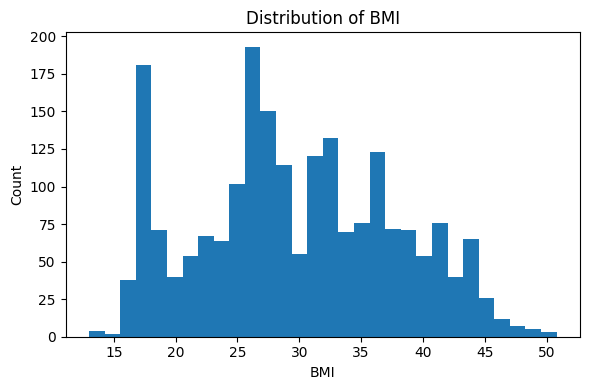

In [15]:
# =========================
# 4) Add BMI feature
# =========================
if "Height" in df.columns and "Weight" in df.columns:
    h = df["Height"].astype(float)
    # Heuristic: if height looks like centimeters, convert
    h_m = h / 100.0 if h.median() > 3.0 else h
    df["BMI"] = df["Weight"].astype(float) / (h_m ** 2)
    print("Added BMI ")
    hist_plot(df["BMI"], "Distribution of BMI")
else:
    print("Height/Weight missing; skipping BMI.")

# Correlation Matrix Heatmap (with values)

To match common “Kaggle-style” notebooks, we build a correlation heatmap **with values shown inside each cell**.

Important notes:
- Correlation requires numeric values.
- For this visualization **only**, we temporarily convert categorical columns (e.g., Gender, CAEC, MTRANS) to numeric codes.
- This does **not** affect the modeling pipeline (which still uses One-Hot Encoding + Scaling).

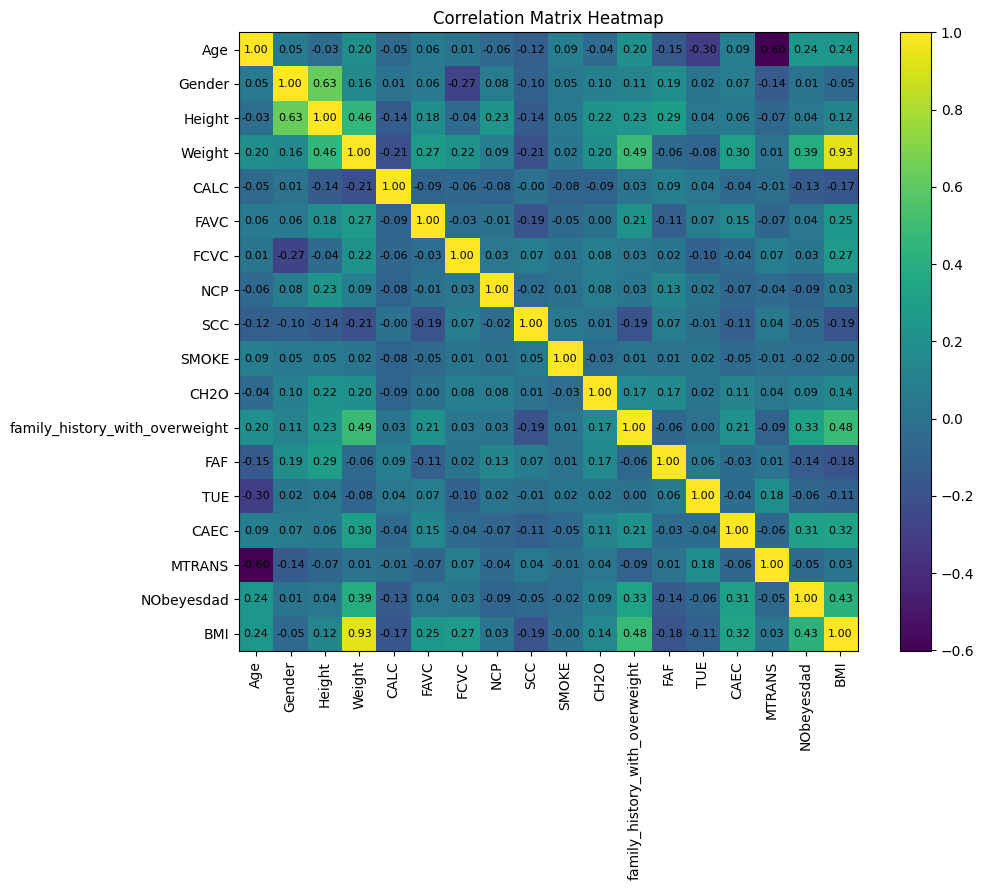

In [16]:
# =========================
# Correlation Matrix Heatmap (Annotated)
# - Converts categorical columns to codes for visualization only
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Copy to avoid changing the original df used for modeling
corr_df = df.copy()

# Encode categorical columns as integer codes (visualization only)
for col in corr_df.columns:
    if corr_df[col].dtype == "object":
        corr_df[col] = corr_df[col].astype("category").cat.codes

# Ensure target is numeric codes too (if not already)
if TARGET in corr_df.columns and corr_df[TARGET].dtype == "object":
    corr_df[TARGET] = corr_df[TARGET].astype("category").cat.codes

# Compute correlation
corr = corr_df.corr(numeric_only=True)

# Plot heatmap with annotations
plt.figure(figsize=(12, 9))
im = plt.imshow(corr.values, interpolation="nearest")

plt.title("Correlation Matrix Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add numbers in each cell (rounded to 2 decimals)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j, i,
            f"{corr.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5) Train/Test split + Preprocessing

We auto-detect:
- categorical columns (`object`)
- numeric columns (`int/float`)

Preprocessing:
- numeric → `StandardScaler`
- categorical → `OneHotEncoder(handle_unknown="ignore")`

In [17]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Categorical columns: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
Train shape: (1669, 17) Test shape: (418, 17)


---
# Pattern Discovery & Association Rules


## Setup (Association Rules Library)
We use `mlxtend` to run the Apriori algorithm and generate association rules.

In [18]:
!pip -q install mlxtend

## Pattern Discovery (Unsupervised Learning): K-Means Clustering + PCA

This section discovers hidden structure in the data without using the target label:
- **K-Means** clustering
- **Elbow method** (choose k)
- **Silhouette score** (cluster quality)
- **PCA** for 2D visualization

Notes:
- We cluster using the same preprocessed feature matrix (encoded + scaled).
- PCA is only for visualization.

Clustering feature matrix shape: (2087, 32)


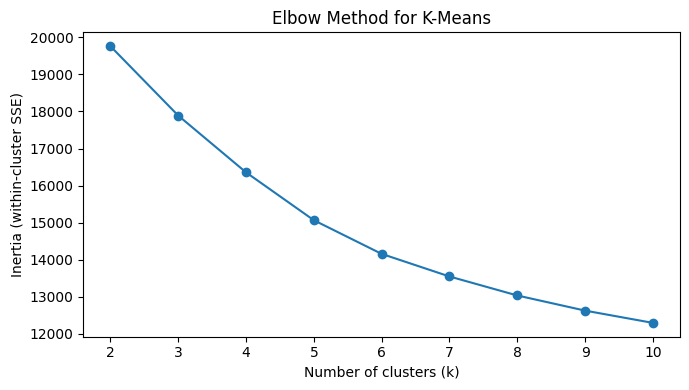

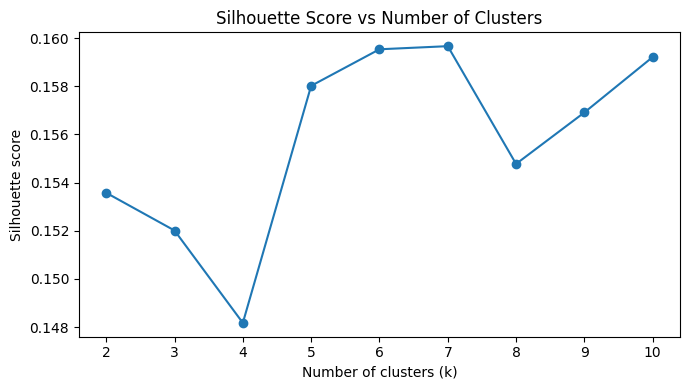

Best k by silhouette: 7


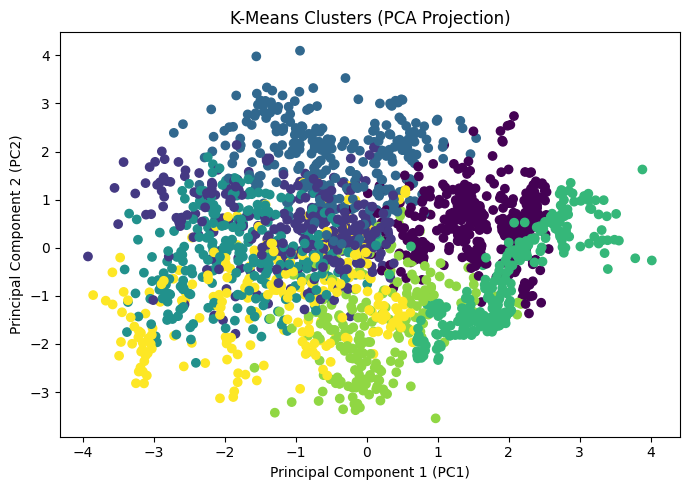

Cluster means (numeric features):


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Cluster
Cluster,,,,,,,,,,
0,27.190,1.803,111.636,2.272,2.778,2.164,0.985,0.525,34.364,0.0
1,21.366,1.700,73.235,1.850,3.002,1.782,0.604,1.003,25.354,1.0
2,20.697,1.768,75.111,2.391,3.120,2.402,2.144,0.858,24.124,2.0
3,20.585,1.623,57.447,2.680,3.060,1.789,1.140,0.610,21.888,3.0
4,23.483,1.687,120.714,2.999,3.001,2.200,0.675,0.605,42.214,4.0
5,36.848,1.654,82.541,2.431,2.514,1.701,0.917,0.218,30.132,5.0
6,21.673,1.634,72.820,2.368,1.137,1.860,0.668,0.763,27.101,6.0


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ----------------------------
# Build a numeric feature matrix for clustering
# ----------------------------
# We try to reuse your existing preprocessing pipeline if it exists.
# Common variable names in notebooks: X, y, preprocessor, pipeline, model, best_model.
#
# If `preprocessor` exists (ColumnTransformer), we use it to transform X (no labels used).
# Otherwise, we fall back to numeric-only scaling (still valid for clustering).
if "X" in globals():
    X_for_cluster = X.copy()
else:
    # If your notebook uses different variable names, adjust here.
    X_for_cluster = df.drop(TARGET, axis=1).copy()

if "preprocess" in globals():
    _prep = preprocess
elif "preprocessor" in globals():
    _prep = preprocessor
else:
    _prep = None

if _prep is not None:
    X_mat = _prep.fit_transform(X_for_cluster)
    # Convert sparse -> dense for PCA and some plotting (safe for this dataset size)
    try:
        X_mat = X_mat.toarray()
    except Exception:
        pass
else:
    # Fallback: numeric-only clustering
    num_cols = X_for_cluster.select_dtypes(include=[np.number]).columns
    from sklearn.preprocessing import StandardScaler
    X_mat = StandardScaler().fit_transform(X_for_cluster[num_cols])

print("Clustering feature matrix shape:", X_mat.shape)

# ----------------------------
# Elbow method (Inertia)
# ----------------------------
ks = range(2, 11)
inertia = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_mat)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.tight_layout()
plt.show()

# ----------------------------
# Silhouette scores (optional but useful)
# ----------------------------
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_mat)
    sil = silhouette_score(X_mat, labels_k)
    sil_scores.append(sil)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

# Choose k with highest silhouette (simple rule)
best_k = int(list(ks)[int(np.argmax(sil_scores))])
print("Best k by silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_mat)

# ----------------------------
# PCA visualization (2D)
# ----------------------------
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_mat)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.tight_layout()
plt.show()

# ----------------------------
# Cluster summary (interpretable)
# ----------------------------
# Use original (non-encoded) columns for interpretation where possible.
cluster_summary = X_for_cluster.copy()
cluster_summary["Cluster"] = cluster_labels

# Show numeric means per cluster
num_cols2 = cluster_summary.select_dtypes(include=[np.number]).columns
print("Cluster means (numeric features):")
display(cluster_summary.groupby("Cluster")[num_cols2].mean().round(3))

## Pattern Discovery (Association Rules): Apriori

We use the classic **Apriori algorithm** to discover rules such as:
- **IF** (BMI is high AND physical activity is low) **THEN** (Obesity_Type_II)

Because Apriori requires transaction-style data, we:
1) Convert each row into a set of **items**
2) Discretize key numeric features into **bins** (e.g., BMI categories)
3) Mine frequent itemsets and rules using **support, confidence, lift**

This implementation is optimized for **free Colab** (smaller item space + `max_len`).

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ----------------------------
# 1) Prepare a small, meaningful subset of columns
# ----------------------------
# Adjust TARGET if your notebook uses a different name
if "TARGET" not in globals():
    TARGET = "NObeyesdad"

# Ensure BMI exists
if "BMI" not in df.columns and "Height" in df.columns and "Weight" in df.columns:
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

cols_for_rules = [
    "Age", "BMI", "FAF", "TUE",
    "CAEC", "CALC", "FAVC",
    "family_history_with_overweight",
    TARGET
]

ap = df[cols_for_rules].copy()

# ----------------------------
# 2) Discretize numeric features into readable bins
# ----------------------------
ap["BMI_Bin"] = pd.cut(
    ap["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II", "Obese_III"]
)

ap["Age_Bin"] = pd.cut(
    ap["Age"],
    bins=[0, 20, 30, 40, 50, 100],
    labels=["<=20", "21-30", "31-40", "41-50", "51+"]
)

ap["FAF_Bin"] = pd.cut(
    ap["FAF"],
    bins=[-0.1, 0.5, 1.5, 2.5, 10],
    labels=["Low", "Mid", "High", "VeryHigh"]
)

ap["TUE_Bin"] = pd.cut(
    ap["TUE"],
    bins=[-0.1, 0.5, 1.5, 2.5, 10],
    labels=["Low", "Mid", "High", "VeryHigh"]
)

# ----------------------------
# 3) Build transactions (list of items per row)
# ----------------------------
transactions = []
for _, row in ap.iterrows():
    items = [
        f"BMI={row['BMI_Bin']}",
        f"Age={row['Age_Bin']}",
        f"FAF={row['FAF_Bin']}",
        f"TUE={row['TUE_Bin']}",
        f"CAEC={row['CAEC']}",
        f"CALC={row['CALC']}",
        f"FAVC={row['FAVC']}",
        f"FamilyHistory={row['family_history_with_overweight']}",
        f"Label={row[TARGET]}"
    ]
    transactions.append(items)

# ----------------------------
# 4) One-hot encode transactions
# ----------------------------
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
tx_df = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)

print("Transactions:", tx_df.shape[0], "Items:", tx_df.shape[1])

# ----------------------------
# 5) Frequent itemsets + rules (tuned for free Colab)
# ----------------------------
min_support = 0.08  # increase if slow: 0.10 or 0.12
freq_itemsets = apriori(
    tx_df,
    min_support=min_support,
    use_colnames=True,
    max_len=3  # limits itemset size -> big speed/RAM improvement
)

print("Frequent itemsets:", freq_itemsets.shape[0])

rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)

print("Rules generated:", rules.shape[0])
rules.head(10)

Transactions: 2087 Items: 37
Frequent itemsets: 429
Rules generated: 711


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(Label=Insufficient_Weight, Age=<=20)",(BMI=Underweight),0.085769,0.127456,0.085290,0.994413,7.802033,1.0,0.074358,156.185434,0.953619,0.666667,0.993597,0.831793
1,(BMI=Underweight),"(Label=Insufficient_Weight, Age=<=20)",0.127456,0.085769,0.085290,0.669173,7.802033,1.0,0.074358,2.763471,0.999179,0.666667,0.638136,0.831793
2,"(FAVC=yes, BMI=Underweight)",(Label=Insufficient_Weight),0.103019,0.127935,0.102060,0.990698,7.743768,1.0,0.088881,93.747005,0.970883,0.791822,0.989333,0.894225
3,(Label=Insufficient_Weight),"(FAVC=yes, BMI=Underweight)",0.127935,0.103019,0.102060,0.797753,7.743768,1.0,0.088881,4.435074,0.998623,0.791822,0.774525,0.894225
4,"(Age=<=20, BMI=Underweight)",(Label=Insufficient_Weight),0.086248,0.127935,0.085290,0.988889,7.729630,1.0,0.074256,78.485865,0.952805,0.661710,0.987259,0.827778
5,(Label=Insufficient_Weight),"(Age=<=20, BMI=Underweight)",0.127935,0.086248,0.085290,0.666667,7.729630,1.0,0.074256,2.741255,0.998352,0.661710,0.635204,0.827778
6,(BMI=Underweight),(Label=Insufficient_Weight),0.127456,0.127935,0.126018,0.988722,7.728324,1.0,0.109712,77.323111,0.997778,0.974074,0.987067,0.986870
7,(Label=Insufficient_Weight),(BMI=Underweight),0.127935,0.127456,0.126018,0.985019,7.728324,1.0,0.109712,58.242333,0.998327,0.974074,0.982830,0.986870
8,"(Label=Insufficient_Weight, FAVC=yes)",(BMI=Underweight),0.103977,0.127456,0.102060,0.981567,7.701240,1.0,0.088808,47.335529,0.971126,0.788889,0.978874,0.891159
9,(BMI=Underweight),"(Label=Insufficient_Weight, FAVC=yes)",0.127456,0.103977,0.102060,0.800752,7.701240,1.0,0.088808,4.497021,0.997257,0.788889,0.777631,0.891159


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# ----------------------------
# 6) Focus rules that predict the target label (Label=...)
# ----------------------------
def set_to_str(s):
    """Convert frozenset to a sorted, readable string."""
    return ", ".join(sorted(list(s)))

label_rules = rules[rules["consequents"].astype(str).str.contains("Label=")].copy()

if label_rules.empty:
    print("No label rules at current thresholds. Try increasing data (or lowering min_support / confidence).")
else:
    show_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
    out = label_rules[show_cols].head(15).copy()
    out["antecedents"] = out["antecedents"].apply(set_to_str)
    out["consequents"] = out["consequents"].apply(set_to_str)
    display(out)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
1,BMI=Underweight,"Age=<=20, Label=Insufficient_Weight",0.085290,0.669173,7.802033
2,"BMI=Underweight, FAVC=yes",Label=Insufficient_Weight,0.102060,0.990698,7.743768
4,"Age=<=20, BMI=Underweight",Label=Insufficient_Weight,0.085290,0.988889,7.729630
6,BMI=Underweight,Label=Insufficient_Weight,0.126018,0.988722,7.728324
9,BMI=Underweight,"FAVC=yes, Label=Insufficient_Weight",0.102060,0.800752,7.701240
11,BMI=Normal,"FAVC=yes, Label=Normal_Weight",0.096790,0.684746,7.005218
13,BMI=Normal,Label=Normal_Weight,0.133685,0.945763,6.999315
14,"BMI=Normal, FAVC=yes",Label=Normal_Weight,0.096790,0.926606,6.857538
20,BMI=Obese_III,Label=Obesity_Type_III,0.128414,1.000000,6.441358
21,"BMI=Obese_III, FamilyHistory=yes",Label=Obesity_Type_III,0.128414,1.000000,6.441358


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

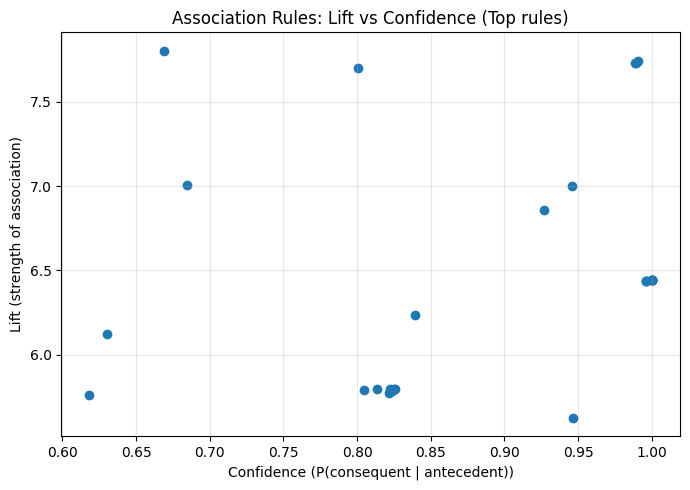

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
# ----------------------------
# 7) Plot: Lift vs Confidence (readable axes)
# ----------------------------
if label_rules.empty:
    print("No rules to plot. Lower thresholds and re-run.")
else:
    top_n = min(30, len(label_rules))
    plot_df = label_rules.head(top_n)

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df["confidence"], plot_df["lift"])
    plt.title("Association Rules: Lift vs Confidence (Top rules)")
    plt.xlabel("Confidence (P(consequent | antecedent))")
    plt.ylabel("Lift (strength of association)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [23]:
# Helper: GaussianNB needs dense arrays after one-hot encoding
class ToDense(BaseEstimator, TransformerMixin):
    """Convert sparse matrix to dense for models that require dense input."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Modeling (Required Models)
We train:
- **Gaussian Naive Bayes**
- **Logistic Regression**
- **SVM (LinearSVC) calibrated** → enables `predict_proba()` for Streamlit

In [24]:
# =========================
# 6) Define required models
# =========================
pipe_nb = Pipeline([
    ("prep", preprocess),
    ("dense", ToDense()),
    ("clf", GaussianNB())
])

pipe_lr = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=500, solver="lbfgs"))
])

svm_base = Pipeline([
    ("prep", preprocess),
    ("clf", LinearSVC())
])

# Calibrate to get probabilities
pipe_svm = CalibratedClassifierCV(estimator=svm_base, method="sigmoid", cv=3)

models_required = {
    "GaussianNB": pipe_nb,
    "LogisticRegression": pipe_lr,
    "LinearSVM_Calibrated": pipe_svm
}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Modeling (Optional Extra Models)
These are optional but make your notebook look more “complete” like the examples:
- Decision Tree
- Random Forest
- AdaBoost
- Voting Classifier (ensemble)

In [25]:
# Optional models
pipe_dt = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_ada = Pipeline([
    ("prep", preprocess),
    ("clf", AdaBoostClassifier(random_state=42))
])

# Voting: combine LR + RF + calibrated SVM probabilities (soft vote)
# Note: For soft voting, all estimators need predict_proba; we use calibrated SVM.
pipe_vote = VotingClassifier(
    estimators=[
        ("lr", pipe_lr),
        ("rf", pipe_rf),
        ("svm", pipe_svm)
    ],
    voting="soft"
)

models_optional = {
    "DecisionTree": pipe_dt,
    "RandomForest": pipe_rf,
    "AdaBoost": pipe_ada,
    "VotingClassifier": pipe_vote
}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Train + Evaluate
We report:
- Accuracy
- Macro F1 (best for multi-class imbalance)
- Classification report

In [26]:
def evaluate_model(name, model, X_te, y_te):
    """Evaluate a fitted model and return metrics + predictions."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    return acc, f1m, y_pred

def train_and_compare(model_dict):
    results = []
    fitted = {}
    for name, model in model_dict.items():
        print("\n==============================")
        print("Training:", name)
        model.fit(X_train, y_train)
        fitted[name] = model

        acc, f1m, y_pred = evaluate_model(name, model, X_test, y_test)
        results.append((name, acc, f1m))
        print(f"Accuracy: {acc:.4f}")
        print(f"Macro F1: {f1m:.4f}")
        print(classification_report(y_test, y_pred))
    res_df = pd.DataFrame(results, columns=["Model", "Accuracy", "MacroF1"]).sort_values("MacroF1", ascending=False)
    return res_df, fitted

# Train required models
res_req, fitted_req = train_and_compare(models_required)
display(res_req)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Training: GaussianNB
Accuracy: 0.6364
Macro F1: 0.6120
                     precision    recall  f1-score   support

Insufficient_Weight       0.71      0.96      0.82        53
      Normal_Weight       0.61      0.30      0.40        57
     Obesity_Type_I       0.88      0.51      0.65        70
    Obesity_Type_II       0.42      0.95      0.58        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.55      0.49      0.52        55
Overweight_Level_II       0.52      0.24      0.33        58

           accuracy                           0.64       418
          macro avg       0.67      0.63      0.61       418
       weighted avg       0.68      0.64      0.62       418


Training: LogisticRegression


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 0.9258
Macro F1: 0.9230
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.89      0.86      0.88        57
     Obesity_Type_I       0.96      0.94      0.95        70
    Obesity_Type_II       0.94      1.00      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.84      0.85      0.85        55
Overweight_Level_II       0.89      0.83      0.86        58

           accuracy                           0.93       418
          macro avg       0.92      0.92      0.92       418
       weighted avg       0.93      0.93      0.93       418


Training: LinearSVM_Calibrated


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 0.7823
Macro F1: 0.7718
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94        53
      Normal_Weight       0.68      0.56      0.62        57
     Obesity_Type_I       0.67      0.84      0.75        70
    Obesity_Type_II       0.89      0.98      0.94        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.71      0.62      0.66        55
Overweight_Level_II       0.57      0.47      0.51        58

           accuracy                           0.78       418
          macro avg       0.77      0.78      0.77       418
       weighted avg       0.78      0.78      0.77       418



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Accuracy,MacroF1
1,LogisticRegression,0.925837,0.923014
2,LinearSVM_Calibrated,0.782297,0.771770
0,GaussianNB,0.636364,0.612031


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [27]:
# Train optional models (you can skip this cell if you want)
res_opt, fitted_opt = train_and_compare(models_optional)
display(res_opt)


Training: DecisionTree
Accuracy: 0.9689
Macro F1: 0.9681
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.97      1.00      0.98        57
     Obesity_Type_I       0.97      0.99      0.98        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.91      0.93        55
Overweight_Level_II       0.93      0.93      0.93        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418


Training: RandomForest


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 0.9785
Macro F1: 0.9776
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.89      1.00      0.94        57
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.91      0.95        55
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418


Training: AdaBoost


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 0.7081
Macro F1: 0.6571
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       1.00      0.05      0.10        57
     Obesity_Type_I       1.00      0.96      0.98        70
    Obesity_Type_II       0.88      0.93      0.90        60
   Obesity_Type_III       0.94      0.91      0.92        65
 Overweight_Level_I       0.03      0.04      0.04        55
Overweight_Level_II       0.51      0.97      0.67        58

           accuracy                           0.71       418
          macro avg       0.76      0.69      0.66       418
       weighted avg       0.78      0.71      0.67       418


Training: VotingClassifier


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Accuracy: 0.9402
Macro F1: 0.9385
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.85      0.93      0.89        57
     Obesity_Type_I       0.97      0.94      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.90      0.85      0.88        55
Overweight_Level_II       0.91      0.86      0.88        58

           accuracy                           0.94       418
          macro avg       0.94      0.94      0.94       418
       weighted avg       0.94      0.94      0.94       418



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Accuracy,MacroF1
1,RandomForest,0.978469,0.977558
0,DecisionTree,0.968900,0.968053
3,VotingClassifier,0.940191,0.938464
2,AdaBoost,0.708134,0.657131


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Select best model (from required + optional)
We choose the model with the highest **Macro F1**.

In [28]:
# Combine results and pick best
all_results = pd.concat([res_req, res_opt], ignore_index=True)
all_results = all_results.sort_values("MacroF1", ascending=False).reset_index(drop=True)
display(all_results)

best_name = all_results.loc[0, "Model"]

# Find the fitted model by name
best_model = None
if best_name in fitted_req:
    best_model = fitted_req[best_name]
elif best_name in fitted_opt:
    best_model = fitted_opt[best_name]
else:
    raise RuntimeError("Best model not found in fitted models dicts.")

print("Best model:", best_name)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Model,Accuracy,MacroF1
0,RandomForest,0.978469,0.977558
1,DecisionTree,0.968900,0.968053
2,VotingClassifier,0.940191,0.938464
3,LogisticRegression,0.925837,0.923014
4,LinearSVM_Calibrated,0.782297,0.771770
5,AdaBoost,0.708134,0.657131
6,GaussianNB,0.636364,0.612031


Best model: RandomForest


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Confusion Matrix (Best Model)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

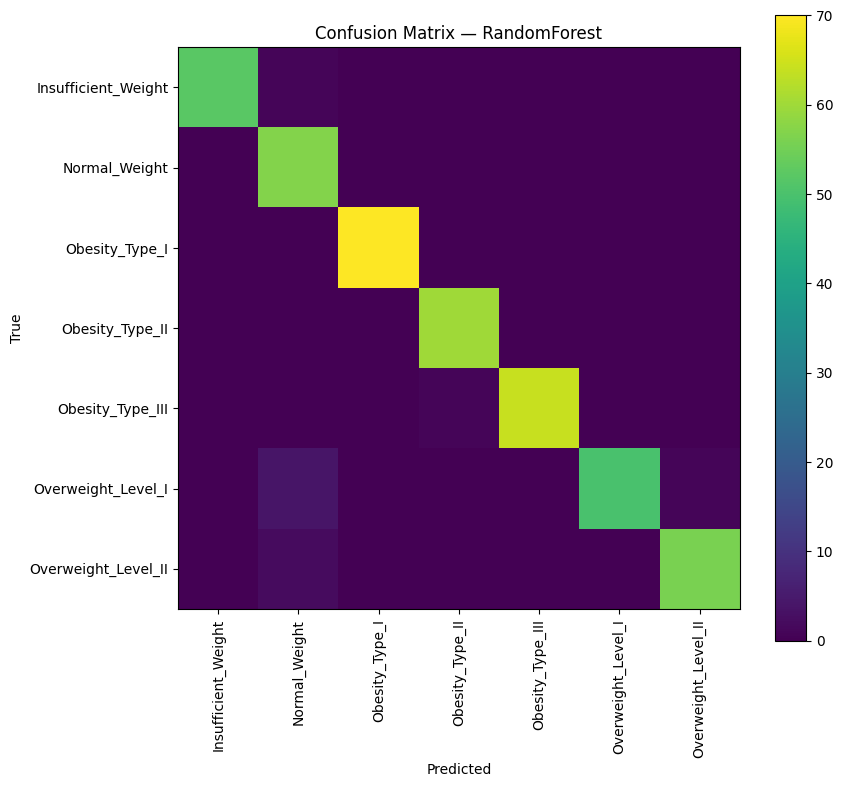

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
y_pred_best = best_model.predict(X_test)
labels = np.unique(y)

cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(9, 8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

# Example Prediction + Top‑5 Probabilities
Works because the best model is likely LR/RF/Voting or a **calibrated** SVM.

In [30]:
def topk_predictions(model, row_dict, k=5):
    """Predict top-k classes from a single input row dict."""
    x_in = pd.DataFrame([row_dict])
    probs = model.predict_proba(x_in)[0]
    classes = model.classes_
    top_idx = np.argsort(probs)[::-1][:k]
    return [(classes[i], float(probs[i])) for i in top_idx]

# Build a safe sample input (median/mode)
sample = {}
for c in num_cols:
    sample[c] = float(df[c].median())
for c in cat_cols:
    sample[c] = str(df[c].mode().iloc[0])

print("Sample input:", sample)
print("\nTop-5 predicted classes:")
for cls, p in topk_predictions(best_model, sample, k=5):
    print(f"{cls}: {p:.3f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sample input: {'Age': 22.847618, 'Height': 1.701584, 'Weight': 83.1011, 'FCVC': 2.396265, 'NCP': 3.0, 'CH2O': 2.0, 'FAF': 1.0, 'TUE': 0.630866, 'BMI': 28.89622426303332, 'Gender': 'Male', 'CALC': 'Sometimes', 'FAVC': 'yes', 'SCC': 'no', 'SMOKE': 'no', 'family_history_with_overweight': 'yes', 'CAEC': 'Sometimes', 'MTRANS': 'Public_Transportation'}

Top-5 predicted classes:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Overweight_Level_II: 0.800
Overweight_Level_I: 0.143
Obesity_Type_I: 0.050
Normal_Weight: 0.003
Obesity_Type_II: 0.003


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Save model for Streamlit
We save:
- `obesity_best_model.joblib` (full pipeline)
- `schema.json` (to build Streamlit inputs automatically)

In [31]:
ART_DIR = "/content/artifacts"
os.makedirs(ART_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ART_DIR, "obesity_best_model.joblib")
SCHEMA_PATH = os.path.join(ART_DIR, "schema.json")

joblib.dump(best_model, MODEL_PATH)

schema = {
    "target": TARGET,
    "recommended_model": best_name,
    "classes": labels.tolist(),
    "numeric_features": {},
    "categorical_features": {}
}

for c in num_cols:
    schema["numeric_features"][c] = {
        "min": float(df[c].min()),
        "max": float(df[c].max()),
        "median": float(df[c].median())
    }

for c in cat_cols:
    schema["categorical_features"][c] = {
        "options": sorted(df[c].astype(str).unique().tolist()),
        "default": str(df[c].mode().iloc[0])
    }

with open(SCHEMA_PATH, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved schema:", SCHEMA_PATH)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved model: /content/artifacts/obesity_best_model.joblib
Saved schema: /content/artifacts/schema.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
# Download artifacts to your computer
from google.colab import files
files.download(MODEL_PATH)
files.download(SCHEMA_PATH)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag